In [2]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))
print("Device name:", tf.test.gpu_device_name())

gpus = tf.config.list_physical_devices("GPU")
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)

TF version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Device name: /device:GPU:0


In [3]:
import os, urllib.request, zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

HAR_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
HAR_DIR = "/content/uci_har"
os.makedirs(HAR_DIR, exist_ok=True)

zip_path = f"{HAR_DIR}/uci_har.zip"
if not os.path.exists(zip_path):
    print("Downloading UCI HAR...")
    urllib.request.urlretrieve(HAR_URL, zip_path)
    print(f"Downloaded: {os.path.getsize(zip_path)/1e6:.1f} MB")

if not os.path.exists(f"{HAR_DIR}/UCI HAR Dataset"):
    print("Unzipping...")
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(HAR_DIR)

ROOT_HAR = f"{HAR_DIR}/UCI HAR Dataset"
print("\nContents:")
for f in sorted(os.listdir(ROOT_HAR)):
    print(" ", f)

Downloaded: 61.0 MB
Unzipping...

Contents:
  .DS_Store
  README.txt
  activity_labels.txt
  features.txt
  features_info.txt
  test
  train


In [4]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))
print("Device name:", tf.test.gpu_device_name())

gpus = tf.config.list_physical_devices("GPU")
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)

TF version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Device name: /device:GPU:0


In [5]:
import os

for root, dirs, files in os.walk("/content/uci_har"):
    depth = root.replace("/content/uci_har", "").count(os.sep)
    indent = "  " * depth
    print(f"{indent}{os.path.basename(root)}/")
    if depth >= 3: continue
    for f in sorted(files)[:10]:
        print(f"{indent}  {f}")

uci_har/
  uci_har.zip
  UCI HAR Dataset/
    .DS_Store
    README.txt
    activity_labels.txt
    features.txt
    features_info.txt
    train/
      X_train.txt
      subject_train.txt
      y_train.txt
      Inertial Signals/
    test/
      X_test.txt
      subject_test.txt
      y_test.txt
      Inertial Signals/
  __MACOSX/
    ._UCI HAR Dataset
    UCI HAR Dataset/
      ._.DS_Store
      ._README.txt
      ._activity_labels.txt
      ._features.txt
      ._features_info.txt
      ._test
      ._train
      train/
        Inertial Signals/
      test/
        Inertial Signals/


In [6]:
import numpy as np

ROOT_HAR = "/content/uci_har/UCI HAR Dataset"

def load_uci_har_split(split):
    base = f"{ROOT_HAR}/{split}/Inertial Signals"
    channels = ["total_acc_x","total_acc_y","total_acc_z",
                "body_gyro_x","body_gyro_y","body_gyro_z"]
    arrs = [np.loadtxt(f"{base}/{ch}_{split}.txt", dtype=np.float32) for ch in channels]
    y_path = f"{ROOT_HAR}/{split}/y_{split}.txt"
    s_path = f"{ROOT_HAR}/{split}/subject_{split}.txt"
    X = np.stack(arrs, axis=-1)
    y = np.loadtxt(y_path, dtype=int) - 1
    subj = np.loadtxt(s_path, dtype=int)
    return X, y, subj

X_tr, y_tr, s_tr = load_uci_har_split("train")
X_te, y_te, s_te = load_uci_har_split("test")

LABELS = ["WALKING","WALK_UP","WALK_DN","SITTING","STANDING","LAYING"]
print(f"Train: X {X_tr.shape}  y {y_tr.shape}")
print(f"Test:  X {X_te.shape}  y {y_te.shape}")
print(f"Train subjects: {len(np.unique(s_tr))} ({sorted(np.unique(s_tr))})")
print(f"Test subjects:  {len(np.unique(s_te))} ({sorted(np.unique(s_te))})")
print(f"\nClass distribution:")
for i, lab in enumerate(LABELS):
    print(f"  {lab}: {(y_tr==i).sum():4d} train  |  {(y_te==i).sum():4d} test")

Train: X (7352, 128, 6)  y (7352,)
Test:  X (2947, 128, 6)  y (2947,)
Train subjects: 21 ([np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)])
Test subjects:  9 ([np.int64(2), np.int64(4), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(18), np.int64(20), np.int64(24)])

Class distribution:
  WALKING: 1226 train  |   496 test
  WALK_UP: 1073 train  |   471 test
  WALK_DN:  986 train  |   420 test
  SITTING: 1286 train  |   491 test
  STANDING: 1374 train  |   532 test
  LAYING: 1407 train  |   537 test


In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.regularizers import l2

def conv_block(x, filters, kernel, stride=1, wd=1e-4, drop=0.1, separable=False):
    if separable:
        y = layers.SeparableConv1D(filters, kernel, strides=stride, padding="same",
                                   depthwise_regularizer=l2(wd),
                                   pointwise_regularizer=l2(wd))(x)
    else:
        y = layers.Conv1D(filters, kernel, strides=stride, padding="same",
                          kernel_regularizer=l2(wd))(x)
    y = layers.BatchNormalization()(y)
    y = layers.Activation("relu")(y)
    y = layers.SpatialDropout1D(drop)(y)
    return y

def residual_block(x, filters, kernel, wd=1e-4, drop=0.1):
    shortcut = x
    y = conv_block(x, filters, kernel, wd=wd, drop=drop)
    y = layers.SeparableConv1D(filters, kernel, padding="same",
                               depthwise_regularizer=l2(wd),
                               pointwise_regularizer=l2(wd))(y)
    y = layers.BatchNormalization()(y)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding="same",
                                 kernel_regularizer=l2(wd))(shortcut)
    y = layers.Add()([y, shortcut])
    y = layers.Activation("relu")(y)
    y = layers.SpatialDropout1D(drop)(y)
    return y

def build_deep_cnn(input_shape, n_classes, wd=1e-4):
    inp = Input(shape=input_shape, name="signal_input")
    x = conv_block(inp, 64, 7, wd=wd)
    x = conv_block(x, 128, 5, wd=wd)
    x = layers.MaxPool1D(2)(x)

    x = residual_block(x, 128, 5, wd=wd)
    x = residual_block(x, 128, 5, wd=wd)
    x = layers.MaxPool1D(2)(x)

    x = residual_block(x, 256, 3, wd=wd)
    x = residual_block(x, 256, 3, wd=wd)
    x = layers.MaxPool1D(2)(x)

    x = residual_block(x, 256, 3, wd=wd)

    x = layers.GlobalAveragePooling1D(name="features")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=l2(wd))(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation="softmax", name="classifier")(x)
    return Model(inp, out, name="DeepCNN_HAR")

model = build_deep_cnn((128, 6), 6)
model.summary(line_length=90)

Model: "DeepCNN_HAR"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape         ┃      Param # ┃ Connected to          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ signal_input             │ (None, 128, 6)       │            0 │ -                     │
│ (InputLayer)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv1d (Conv1D)          │ (None, 128, 64)      │        2,752 │ signal_input[0][0]    │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ batch_normalization      │ (None, 128, 64)      │          256 │ conv1d[0][0]          │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ activation (Activation)  │ (None, 128, 64)      │            0 │ batch_normalization[… │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ spatial_dropout1d        │ (None, 128, 64)      │            0 │ activation[0][0]      │
│ (SpatialDropout1D)       │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv1d_1 (Conv1D)        │ (None, 128, 128)     │       41,088 │ spatial_dropout1d[0]… │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ batch_normalization_1    │ (None, 128, 128)     │          512 │ conv1d_1[0][0]        │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ activation_1             │ (None, 128, 128)     │            0 │ batch_normalization_… │
│ (Activation)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ spatial_dropout1d_1      │ (None, 128, 128)     │            0 │ activation_1[0][0]    │
│ (SpatialDropout1D)       │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ max_pooling1d            │ (None, 64, 128)      │            0 │ spatial_dropout1d_1[… │
│ (MaxPooling1D)           │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ conv1d_2 (Conv1D)        │ (None, 64, 128)      │       82,048 │ max_pooling1d[0][0]   │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ batch_normalization_2    │ (None, 64, 128)      │          512 │ conv1d_2[0][0]        │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ activation_2             │ (None, 64, 128)      │            0 │ batch_normalization_… │
│ (Activation)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ spatial_dropout1d_2      │ (None, 64, 128)      │            0 │ activation_2[0][0]    │
│ (SpatialDropout1D)       │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ separable_conv1d         │ (None, 64, 128)      │       17,152 │ spatial_dropout1d_2[… │
│ (SeparableConv1D)        │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼─────────────────────

 Total params: 1,009,862 (3.85 MB)

 Trainable params: 1,005,382 (3.84 MB)

 Non-trainable params: 4,480 (17.50 KB)

In [8]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

trainval_idx = np.arange(len(X_tr))
tr_idx, va_idx = train_test_split(trainval_idx, test_size=0.2,
                                  stratify=y_tr, random_state=42)
X_train, y_train = X_tr[tr_idx], y_tr[tr_idx]
X_val, y_val = X_tr[va_idx], y_tr[va_idx]

mean = X_train.reshape(-1, 6).mean(0)
std  = X_train.reshape(-1, 6).std(0) + 1e-8
X_train_n = (X_train - mean) / std
X_val_n   = (X_val   - mean) / std
X_test_n  = (X_te    - mean) / std

print(f"Train: {X_train_n.shape}  Val: {X_val_n.shape}  Test: {X_test_n.shape}")
print(f"Channel mean: {mean.round(3)}")
print(f"Channel std:  {std.round(3)}")

def augment(x, y, noise_std=0.02, max_shift=8):
    shift = tf.random.uniform([], -max_shift, max_shift+1, dtype=tf.int32)
    x = tf.roll(x, shift, axis=0)
    x = x + tf.random.normal(tf.shape(x), stddev=noise_std)
    return x, y

BATCH = 64
train_ds = (tf.data.Dataset.from_tensor_slices((X_train_n, y_train))
            .shuffle(4096, seed=42)
            .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(BATCH).prefetch(tf.data.AUTOTUNE))
val_ds = (tf.data.Dataset.from_tensor_slices((X_val_n, y_val))
          .batch(BATCH).prefetch(tf.data.AUTOTUNE))
test_ds = (tf.data.Dataset.from_tensor_slices((X_test_n, y_te))
           .batch(BATCH).prefetch(tf.data.AUTOTUNE))

Train: (5881, 128, 6)  Val: (1471, 128, 6)  Test: (2947, 128, 6)
Channel mean: [ 0.805  0.027  0.086  0.002 -0.001 -0.001]
Channel std:  [0.414 0.391 0.358 0.408 0.383 0.256]


In [9]:
EPOCHS = 120
STEPS_PER_EPOCH = len(X_train_n) // BATCH
WARMUP_EPOCHS = 5
LR_PEAK = 1e-3
LR_MIN = 1e-5
class WarmupCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, peak, min_lr, warmup_steps, total_steps):
        super().__init__()
        self.peak, self.min_lr = peak, min_lr
        self.warmup_steps, self.total_steps = warmup_steps, total_steps
    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warm = tf.cast(self.warmup_steps, tf.float32)
        total = tf.cast(self.total_steps, tf.float32)
        warmup_lr = self.peak * (step / tf.maximum(warm, 1.0))
        progress = (step - warm) / tf.maximum(total - warm, 1.0)
        cos_lr = self.min_lr + 0.5 * (self.peak - self.min_lr) * (1 + tf.cos(np.pi * progress))
        return tf.where(step < warm, warmup_lr, cos_lr)
    def get_config(self):
        return {
            "peak": self.peak, "min_lr": self.min_lr,
            "warmup_steps": self.warmup_steps, "total_steps": self.total_steps,
        }

lr_schedule = WarmupCosine(
    peak=LR_PEAK, min_lr=LR_MIN,
    warmup_steps=WARMUP_EPOCHS * STEPS_PER_EPOCH,
    total_steps=EPOCHS * STEPS_PER_EPOCH,
)

opt = tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4)
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)

model = build_deep_cnn((128, 6), 6)
model.compile(optimizer=opt, loss=loss_fn, metrics=["accuracy"])

ckpt_path = "/content/uci_har/deep_cnn_best.weights.h5"
cbs = [
    tf.keras.callbacks.EarlyStopping(patience=20, monitor="val_accuracy",
                                     mode="max", restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_accuracy",
                                       mode="max", save_best_only=True,
                                       save_weights_only=True, verbose=0),
]

print(f"Training {EPOCHS} epochs max, {STEPS_PER_EPOCH} steps/epoch")
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS,
                    callbacks=cbs, verbose=2)

Training 120 epochs max, 91 steps/epoch
Epoch 1/120
92/92 - 66s - 713ms/step - accuracy: 0.3811 - loss: 2.2411 - val_accuracy: 0.5676 - val_loss: 1.8750
Epoch 2/120
92/92 - 1s - 10ms/step - accuracy: 0.6987 - loss: 1.0556 - val_accuracy: 0.5282 - val_loss: 1.6012
Epoch 3/120
92/92 - 1s - 13ms/step - accuracy: 0.8291 - loss: 0.6883 - val_accuracy: 0.6125 - val_loss: 1.3125
Epoch 4/120
92/92 - 1s - 13ms/step - accuracy: 0.9010 - loss: 0.5193 - val_accuracy: 0.8294 - val_loss: 0.7614
Epoch 5/120
92/92 - 1s - 13ms/step - accuracy: 0.9145 - loss: 0.4613 - val_accuracy: 0.9395 - val_loss: 0.4033
Epoch 6/120
92/92 - 1s - 10ms/step - accuracy: 0.9316 - loss: 0.4087 - val_accuracy: 0.9375 - val_loss: 0.3511
Epoch 7/120
92/92 - 1s - 13ms/step - accuracy: 0.9391 - loss: 0.3840 - val_accuracy: 0.9599 - val_loss: 0.3509
Epoch 8/120
92/92 - 1s - 13ms/step - accuracy: 0.9373 - loss: 0.3842 - val_accuracy: 0.9613 - val_loss: 0.3244
Epoch 9/120
92/92 - 1s - 10ms/step - accuracy: 0.9396 - loss: 0.3719 -

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"UCI HAR test loss: {test_loss:.4f}  test accuracy: {test_acc:.4f}\n")

y_pred = model.predict(test_ds, verbose=0).argmax(axis=1)
print(classification_report(y_te, y_pred, target_names=LABELS, digits=4))

UCI HAR test loss: 0.3742  test accuracy: 0.9410

              precision    recall  f1-score   support

     WALKING     0.9979    0.9456    0.9710       496
     WALK_UP     1.0000    0.9448    0.9716       471
     WALK_DN     0.8955    1.0000    0.9449       420
     SITTING     0.9381    0.8024    0.8650       491
    STANDING     0.8453    0.9549    0.8967       532
      LAYING     0.9908    1.0000    0.9954       537

    accuracy                         0.9410      2947
   macro avg     0.9446    0.9413    0.9408      2947
weighted avg     0.9448    0.9410    0.9407      2947



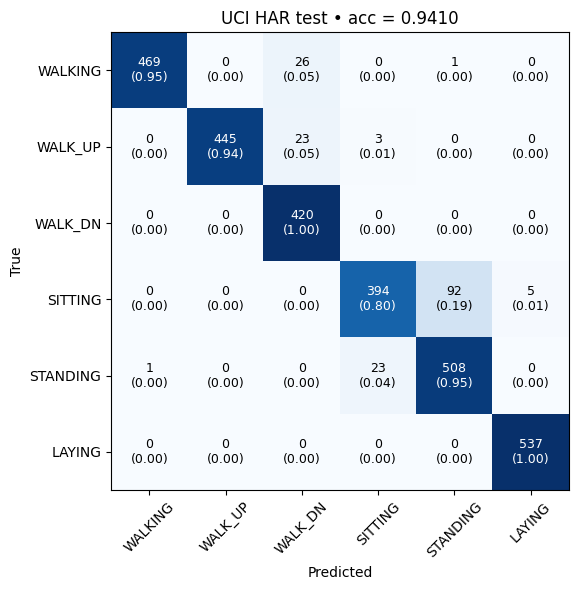

In [11]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_te, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
for i in range(6):
    for j in range(6):
        ax.text(j, i, f"{cm[i,j]}\n({cm_norm[i,j]:.2f})",
                ha="center", va="center",
                color="white" if cm_norm[i,j] > 0.5 else "black", fontsize=9)
ax.set_xticks(range(6)); ax.set_xticklabels(LABELS, rotation=45)
ax.set_yticks(range(6)); ax.set_yticklabels(LABELS)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"UCI HAR test • acc = {test_acc:.4f}")
plt.tight_layout()
plt.savefig("/content/uci_har/cm_uci_har_test.png", dpi=130, bbox_inches="tight")
plt.show()

In [12]:
import pickle

model.save_weights("/content/uci_har/deep_cnn_pretrained.weights.h5")

np.savez("/content/uci_har/pretrain_meta.npz",
         mean=mean, std=std,
         test_acc=test_acc)

with open("/content/uci_har/pretrain_history.pkl", "wb") as f:
    pickle.dump({"history": history.history,
                 "test_acc": float(test_acc),
                 "best_val_acc": float(max(history.history["val_accuracy"]))}, f)

print("Saved:")
print("  deep_cnn_pretrained.weights.h5 — the pretrained CNN")
print("  pretrain_meta.npz — UCI HAR normalization stats")
print("  pretrain_history.pkl — training curves + metrics")

Saved:
  deep_cnn_pretrained.weights.h5 — the pretrained CNN
  pretrain_meta.npz — UCI HAR normalization stats
  pretrain_history.pkl — training curves + metrics


In [14]:
import os, pickle, shutil, numpy as np

os.makedirs("/content/uci_har", exist_ok=True)
model.save_weights("/content/uci_har/deep_cnn_pretrained.weights.h5")
np.savez("/content/uci_har/pretrain_meta.npz", mean=mean, std=std, test_acc=test_acc)
with open("/content/uci_har/pretrain_history.pkl", "wb") as f:
    pickle.dump({"history": history.history,
                 "test_acc": float(test_acc),
                 "best_val_acc": float(max(history.history["val_accuracy"]))}, f)

DRIVE = "/content/drive/MyDrive/uci_har_pretrain"
os.makedirs(DRIVE, exist_ok=True)
for f in ["deep_cnn_pretrained.weights.h5", "pretrain_meta.npz", "pretrain_history.pkl"]:
    shutil.copy(f"/content/uci_har/{f}", f"{DRIVE}/{f}")

import time
time.sleep(5)

print("Local:")
for f in sorted(os.listdir("/content/uci_har")):
    p = f"/content/uci_har/{f}"
    if os.path.isfile(p):
        print(f"  {f} — {os.path.getsize(p)/1e6:.2f} MB")

print("\nDrive:")
for f in sorted(os.listdir(DRIVE)):
    p = f"{DRIVE}/{f}"
    if os.path.isfile(p):
        print(f"  {f} — {os.path.getsize(p)/1e6:.2f} MB")

Local:
  cm_uci_har_test.png — 0.07 MB
  deep_cnn_best.weights.h5 — 12.29 MB
  deep_cnn_pretrained.weights.h5 — 12.29 MB
  pretrain_history.pkl — 0.00 MB
  pretrain_meta.npz — 0.00 MB
  uci_har.zip — 61.00 MB

Drive:
  cm_uci_har_test.png — 0.07 MB
  deep_cnn_best.weights.h5 — 12.29 MB
  deep_cnn_pretrained.weights.h5 — 12.29 MB
  pretrain_history.pkl — 0.00 MB
  pretrain_meta.npz — 0.00 MB
  uci_har.zip — 61.00 MB


In [21]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

def build_target_model(input_shape, n_classes_target, wd=1e-4, head_units=128):
    backbone = build_backbone(input_shape, wd=wd)
    x = layers.Dropout(0.3)(backbone.output)
    x = layers.Dense(head_units, activation="relu", kernel_regularizer=l2(wd),
                     name="head_dense")(x)
    x = layers.Dropout(0.3)(x)
    if n_classes_target == 2:
        out = layers.Dense(1, activation="sigmoid", name="head_out")(x)
    else:
        out = layers.Dense(n_classes_target, activation="softmax", name="head_out")(x)
    return Model(backbone.input, out, name=f"tgt_{n_classes_target}cls")

def transfer_by_position(src_model, tgt_model, stop_before="head_dense"):
    src_layers = [l for l in src_model.layers if l.weights]
    tgt_layers = [l for l in tgt_model.layers if l.weights]
    copied = 0
    for sl, tl in zip(src_layers, tgt_layers):
        if tl.name == stop_before: break
        if all(sw.shape == tw.shape for sw, tw in zip(sl.weights, tl.weights)):
            tl.set_weights(sl.get_weights())
            copied += 1
    return copied

def freeze_backbone(tgt_model, unfreeze=False):
    for l in tgt_model.layers:
        if l.name in ("head_dense", "head_out"): continue
        l.trainable = unfreeze

In [22]:
def load_mobifall(ws, task):
    d = np.load(f"/content/drive/MyDrive/mobifall_processed/mobifall_w{ws}s.npz",
                allow_pickle=True)
    X = d["X"]
    y_subj = d["y_subject"]
    if task == "binary":
        y = d["y_binary"]
    elif task == "fall4":
        mask = d["fall_mask"]
        X, y, y_subj = X[mask], d["y_fall4"][mask], y_subj[mask]
    elif task == "multi13":
        y = d["y_multi13"]
    return X, y, y_subj

def split_and_normalize(X, y, seed=42):
    idx = np.arange(len(X))
    trv, te = train_test_split(idx, test_size=0.2, stratify=y, random_state=seed)
    tr, va = train_test_split(trv, test_size=0.2, stratify=y[trv], random_state=seed)
    mean = X[tr].reshape(-1, 6).mean(0)
    std  = X[tr].reshape(-1, 6).std(0) + 1e-8
    norm = lambda A: (A - mean) / std
    return (norm(X[tr]), y[tr]), (norm(X[va]), y[va]), (norm(X[te]), y[te])

In [23]:
import time

def finetune_transfer(src_model, ws, task, seed=42):
    n_classes = {"binary": 2, "fall4": 4, "multi13": 13}[task]
    X, y, _ = load_mobifall(ws, task)
    (X_tr, y_tr), (X_va, y_va), (X_te, y_te) = split_and_normalize(X, y, seed=seed)
    input_shape = (X_tr.shape[1], 6)

    tgt = build_target_model(input_shape, n_classes)
    copied = transfer_by_position(src_model, tgt)

    loss = "binary_crossentropy" if n_classes == 2 else "sparse_categorical_crossentropy"

    freeze_backbone(tgt, unfreeze=False)
    tgt.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=loss, metrics=["accuracy"])
    t0 = time.time()
    h1 = tgt.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                 epochs=15, batch_size=64, verbose=0,
                 callbacks=[tf.keras.callbacks.EarlyStopping(patience=5,
                            restore_best_weights=True, monitor="val_loss")])
    t_stage1 = time.time() - t0

    freeze_backbone(tgt, unfreeze=True)
    tgt.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss=loss, metrics=["accuracy"])
    t0 = time.time()
    h2 = tgt.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                 epochs=40, batch_size=64, verbose=0,
                 callbacks=[tf.keras.callbacks.EarlyStopping(patience=8,
                            restore_best_weights=True, monitor="val_loss")])
    t_stage2 = time.time() - t0

    probs = tgt.predict(X_te, verbose=0)
    y_pred = (probs.ravel() > 0.5).astype(int) if n_classes == 2 else probs.argmax(1)
    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, average="macro")
    cm  = confusion_matrix(y_te, y_pred)

    return {
        "task": task, "window_s": ws,
        "layers_transferred": copied,
        "acc": acc, "f1_macro": f1, "cm": cm,
        "stage1_epochs": len(h1.history["loss"]),
        "stage2_epochs": len(h2.history["loss"]),
        "time_s": t_stage1 + t_stage2,
        "history": {"stage1": h1.history, "stage2": h2.history},
    }

In [28]:
!umount /content/drive 2>/dev/null
!rm -rf /content/drive
from google.colab import drive
drive.mount("/content/drive")
import os
print(os.listdir("/content/drive/MyDrive/mobifall_processed"))

Mounted at /content/drive
['mobifall_w2s.npz', 'mobifall_w1s.npz', 'mobifall_w3s.npz', 'fig_fall4_cm.png', 'fig_binary_loss.png', 'fig_fall4_multi13_loss.png', 'fig_binary_cm.png', 'task3_multi13_results.pkl', 'fig_multi13_cm.png', 'task3_binary_results.pkl', 'task3_fall4_results.pkl']


In [29]:
r = finetune_transfer(src_model, ws=3, task="binary")
print(f"Layers transferred: {r['layers_transferred']}")
print(f"Stage 1 (frozen): {r['stage1_epochs']} epochs")
print(f"Stage 2 (unfrozen): {r['stage2_epochs']} epochs")
print(f"Test accuracy: {r['acc']:.4f}, F1: {r['f1_macro']:.4f}")
print(f"Time: {r['time_s']:.1f}s")
print(f"\nCompare to Task 3 CNN (no transfer): 0.9935 acc, 0.9931 F1")

Layers transferred: 25
Stage 1 (frozen): 15 epochs
Stage 2 (unfrozen): 40 epochs
Test accuracy: 0.9935, F1: 0.9931
Time: 124.6s

Compare to Task 3 CNN (no transfer): 0.9935 acc, 0.9931 F1


In [30]:
import pickle

transfer_results = []
for ws in [1, 2, 3]:
    for task in ["binary", "fall4", "multi13"]:
        print(f"→ ws={ws}s, task={task} ...", end=" ", flush=True)
        r = finetune_transfer(src_model, ws=ws, task=task)
        transfer_results.append(r)
        print(f"acc={r['acc']:.4f}  f1={r['f1_macro']:.4f}  "
              f"layers={r['layers_transferred']}  "
              f"epochs={r['stage1_epochs']}+{r['stage2_epochs']}  "
              f"time={r['time_s']:.1f}s")

with open("/content/transfer_B_results.pkl", "wb") as f:
    pickle.dump(transfer_results, f)

import pandas as pd
df = pd.DataFrame([{k: v for k, v in r.items() if k not in ["cm","history"]}
                   for r in transfer_results])
df = df[["window_s","task","acc","f1_macro","stage1_epochs","stage2_epochs","time_s"]]
print("\n=== Transfer Learning (UCI HAR → MobiFall) Results ===")
print(df.to_string(index=False))

import shutil, os
os.makedirs("/content/drive/MyDrive/transfer_B", exist_ok=True)
shutil.copy("/content/transfer_B_results.pkl",
            "/content/drive/MyDrive/transfer_B/transfer_B_results.pkl")
print("\nSaved to Drive.")

→ ws=1s, task=binary ... acc=0.9304  f1=0.9303  layers=25  epochs=15+40  time=131.9s
→ ws=1s, task=fall4 ... acc=0.6183  f1=0.6049  layers=25  epochs=15+40  time=100.0s
→ ws=1s, task=multi13 ... acc=0.6690  f1=0.6846  layers=25  epochs=15+40  time=127.7s
→ ws=2s, task=binary ... acc=0.9651  f1=0.9634  layers=25  epochs=15+40  time=124.6s
→ ws=2s, task=fall4 ... acc=0.6263  f1=0.6169  layers=25  epochs=9+40  time=96.9s
→ ws=2s, task=multi13 ... acc=0.7925  f1=0.7830  layers=25  epochs=15+40  time=117.0s
→ ws=3s, task=binary ... acc=0.9908  f1=0.9903  layers=25  epochs=15+40  time=110.0s
→ ws=3s, task=fall4 ... acc=0.6055  f1=0.6107  layers=25  epochs=8+40  time=99.6s
→ ws=3s, task=multi13 ... acc=0.8418  f1=0.8434  layers=25  epochs=15+40  time=112.7s

=== Transfer Learning (UCI HAR → MobiFall) Results ===
 window_s    task      acc  f1_macro  stage1_epochs  stage2_epochs     time_s
        1  binary 0.930403  0.930319             15             40 131.938242
        1   fall4 0.618269 